# Taller — Aprendizaje No Supervisado: Segmentacion de Jugadores de Steam
## Dataset: Steam Video Games (200,000 interacciones)

**Dataset:** `steam-200k.csv` — 200,000 registros de interacciones usuario-videojuego
**Fuente:** [Kaggle — Steam Video Games](https://www.kaggle.com/datasets/tamber/steam-video-games)
**Objetivo del negocio:** Segmentar a los usuarios de Steam según su comportamiento de
compra y de juego, para diseñar estrategias de marketing y fidelización diferenciadas
por tipo de jugador.

**Contenido del taller:**
- Parte 1 — Exploración de los datos
- Parte 2 — Preparación de los datos
- Parte 3 — Modelado (clustering)
- Parte 4 — Interpretación de los clusters
- Parte 5 — Recomendaciones de negocio

---
**Archivo requerido:** `steam-200k.csv` en la misma carpeta que este notebook.
**Nota sobre el archivo:** el CSV de Kaggle no trae encabezados. Sus columnas son, en orden:
`user_id`, `game`, `behavior` (`purchase` o `play`), `value` y una quinta columna que Kaggle
incluye siempre en 0 y que no aporta información (la documentacion oficial del dataset la
describe como un campo sin uso)

## Librerias e importaciones

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')


# Herramientas de Machine Learning de scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Estilo general para todas las graficas del taller
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

---
## Parte 1 — Exploracion de los Datos

El dataset original esta en formato de **interacciones** (una fila por cada evento
usuario-juego), no en formato de usuarios. Antes de pensar en clustering, primero hay
que entender la estructura de estas interacciones.

### 1.1 Carga de datos y primeras filas

In [247]:
# El CSV no trae encabezados, asi que los asignamos manualmente segun la
# documentacion del dataset en Kaggle. La quinta columna ('extra') siempre vale 0
# y no se usa en el analisis; la conservamos por ahora solo para verificarlo.
df = pd.read_csv(
    r"C:\Users\bootcamp\Proyecto-Git\proyecto_bootcamp/steam-200k.csv",
    header=None,
    names=["user_id", "game", "behavior", "value", "extra"],
)

print(f"Archivo cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas")
df.head(10)

Archivo cargado: 200,000 filas y 5 columnas


,user_id,game,behavior,value,extra
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
5,151603712,Spore,play,14.9,0
6,151603712,Fallout New Vegas,purchase,1.0,0
7,151603712,Fallout New Vegas,play,12.1,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
9,151603712,Left 4 Dead 2,play,8.9,0


### 1.2 Dimensiones del dataset

In [248]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Usuarios unicos: {df['user_id'].nunique():,}")
print(f"Juegos unicos: {df['game'].nunique():,}")

Filas: 200,000
Columnas: 5
Usuarios unicos: 12,393
Juegos unicos: 5,155


### 1.3 Tipos de variables

In [249]:
# info() muestra el tipo de dato de cada columna y cuantos valores no nulos hay.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   200000 non-null  int64  
 1   game      200000 non-null  object 
 2   behavior  200000 non-null  object 
 3   value     200000 non-null  float64
 4   extra     200000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.6+ MB


**Lectura de los tipos de datos**

- `user_id` (numerico): identificador del usuario de Steam.
- `game` (texto): nombre del videojuego.
- `behavior` (texto/categorica): solo toma dos valores, `purchase` (compra) o `play` (horas jugadas).
- `value` (numerico): su significado depende de `behavior` — si `behavior='purchase'` siempre vale 1.0 (es un indicador de que la compra ocurrio); si `behavior='play'` representa las horas jugadas.
- `extra`: columna constante en 0, sin informacion util. Se elimina en la Parte 2.

### 1.4 Valores nulos

In [250]:
# isnull().sum() cuenta cuantos valores vacios (NaN) hay en cada columna.
df.isnull().sum()

user_id     0
game        0
behavior    0
value       0
extra       0
dtype: int64

### 1.5 Registros duplicados

In [251]:
# duplicated().sum() cuenta cuantas filas son copias exactas de otra fila.
duplicados = df.duplicated().sum()
print(f"Filas totales: {df.shape[0]:,}")
print(f"Duplicados exactos: {duplicados:,}")
print(f"Porcentaje: {duplicados/df.shape[0]*100:.2f}%")

df[df.duplicated(keep=False)].sort_values(['user_id', 'game']).head(6)

Filas totales: 200,000
Duplicados exactos: 707
Porcentaje: 0.35%


,user_id,game,behavior,value,extra
142904,561758,Sid Meier's Civilization IV,purchase,1.0,0
142905,561758,Sid Meier's Civilization IV,purchase,1.0,0
142906,561758,Sid Meier's Civilization IV Beyond the Sword,purchase,1.0,0
142907,561758,Sid Meier's Civilization IV Beyond the Sword,purchase,1.0,0
142908,561758,Sid Meier's Civilization IV Colonization,purchase,1.0,0
142909,561758,Sid Meier's Civilization IV Colonization,purchase,1.0,0


**Nota sobre los duplicados**

Hay 707 filas duplicadas exactas — probablemente errores de carga o de scraping del
dataset original (el mismo usuario, mismo juego, mismo comportamiento y mismo valor
repetido dos veces). Se eliminan en la Parte 2, porque de lo contrario inflarian
artificialmente las horas jugadas o el numero de compras de algunos usuarios.

### 1.6 Estadisticos descriptivos

In [252]:
# describe() sobre 'value' no es muy informativo todavia porque mezcla dos
# significados distintos (compras=1 siempre, horas jugadas=variable). Por eso separamos
# el resumen estadistico segun el tipo de comportamiento.
print("Resumen de 'value' cuando behavior = 'purchase' (deberia ser siempre 1.0):")
print(df.loc[df['behavior'] == 'purchase', 'value'].describe())

print("\nResumen de 'value' cuando behavior = 'play' (horas jugadas):")
print(df.loc[df['behavior'] == 'play', 'value'].describe())

Resumen de 'value' cuando behavior = 'purchase' (deberia ser siempre 1.0):
count    129511.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: value, dtype: float64

Resumen de 'value' cuando behavior = 'play' (horas jugadas):
count    70489.000000
mean        48.878063
std        229.335236
min          0.100000
25%          1.000000
50%          4.500000
75%         19.100000
max      11754.000000
Name: value, dtype: float64


### 1.7 Comportamientos y variables categoricas

In [253]:
# value_counts() nos dice cuantas filas hay de cada tipo de comportamiento.
print(df['behavior'].value_counts())
print()
print(f"Porcentaje 'purchase': {(df['behavior']=='purchase').mean()*100:.1f}%")
print(f"Porcentaje 'play': {(df['behavior']=='play').mean()*100:.1f}%")

behavior
purchase    129511
play         70489
Name: count, dtype: int64

Porcentaje 'purchase': 64.8%
Porcentaje 'play': 35.2%


**Interpretacion**

Hay mas filas de `purchase` (129,511) que de `play` (70,489). Esto es esperable: todo
juego que se juega primero se compra, pero no todo juego que se compra se llega a jugar
(algunos quedan "en el estante" — comprados en ofertas y nunca abiertos). Esta diferencia
sera clave para construir variables de comportamiento en la Parte 2.

### 1.8 Visualizaciones

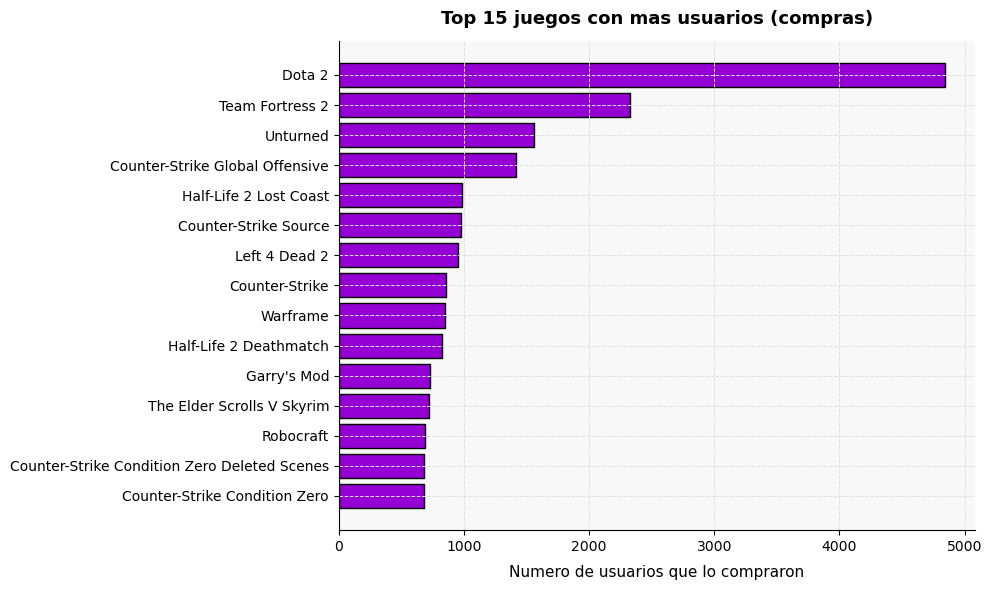

In [254]:
# Grafica 1 — Top 15 juegos con mas compras (popularidad de catalogo)
top_comprados = (df[df['behavior'] == 'purchase']
                  .groupby('game')['user_id'].nunique()
                  .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_comprados.index[::-1], top_comprados.values[::-1], color='#9400D3', edgecolor='Black')
ax.set_xlabel('Numero de usuarios que lo compraron', fontsize=11, labelpad=8)
ax.set_title('Top 15 juegos con mas usuarios (compras)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('grafica_1_top_comprados.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

Dota 2 domina claramente en numero de usuarios: casi 4,900 de los 12,393 usuarios del
dataset lo compraron (cerca del 40%), muy por encima de Team Fortress 2 y Unturned, que
tambien son juegos gratuitos ("free-to-play"). Esto es coherente con el modelo de negocio
de esos titulos: al no tener costo de entrada, casi cualquier usuario de Steam los agrega
a su biblioteca, aunque despues no todos los jueguen activamente.

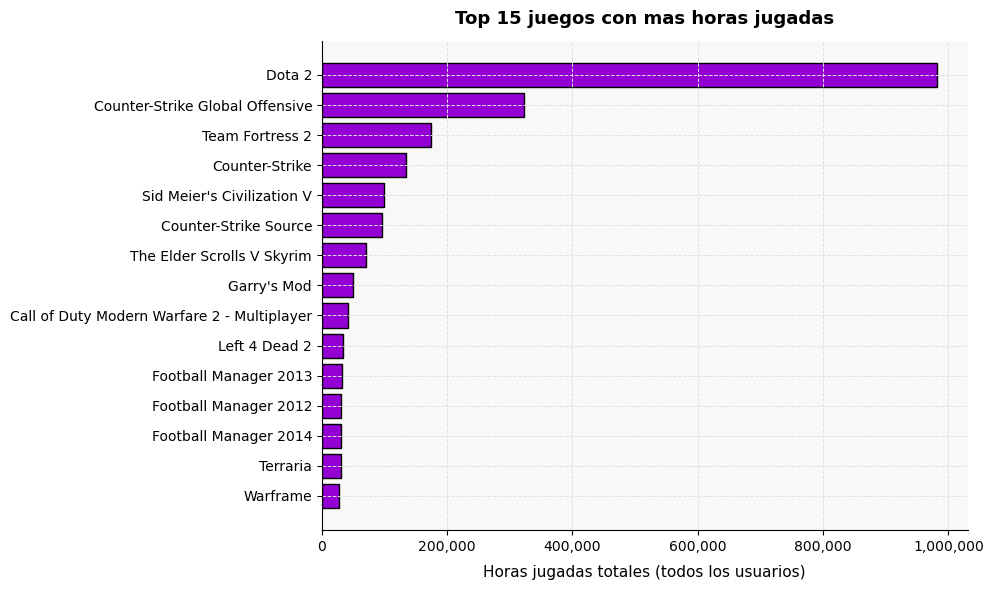

In [255]:
# Grafica 2 — Top 15 juegos con mas horas jugadas en total (compromiso real)
top_horas = (df[df['behavior'] == 'play']
             .groupby('game')['value'].sum()
             .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_horas.index[::-1], top_horas.values[::-1], color='#9400D3', edgecolor='Black')
ax.set_xlabel('Horas jugadas totales (todos los usuarios)', fontsize=11, labelpad=8)
ax.set_title('Top 15 juegos con mas horas jugadas', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('grafica_2_top_horas.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

Dota 2 tambien lidera en horas jugadas totales, con casi un millon de horas acumuladas —
tres veces mas que Counter-Strike Global Offensive, el segundo lugar. Esto confirma que
no solo es el juego mas comprado, sino tambien el que mas retiene a los usuarios que lo
juegan. La comparacion entre esta grafica y la anterior ya insinua la idea central de la
Parte 2: un usuario puede comprar mucho sin jugar mucho, o viceversa, por eso hacen falta
variables que combinen ambas dimensiones.

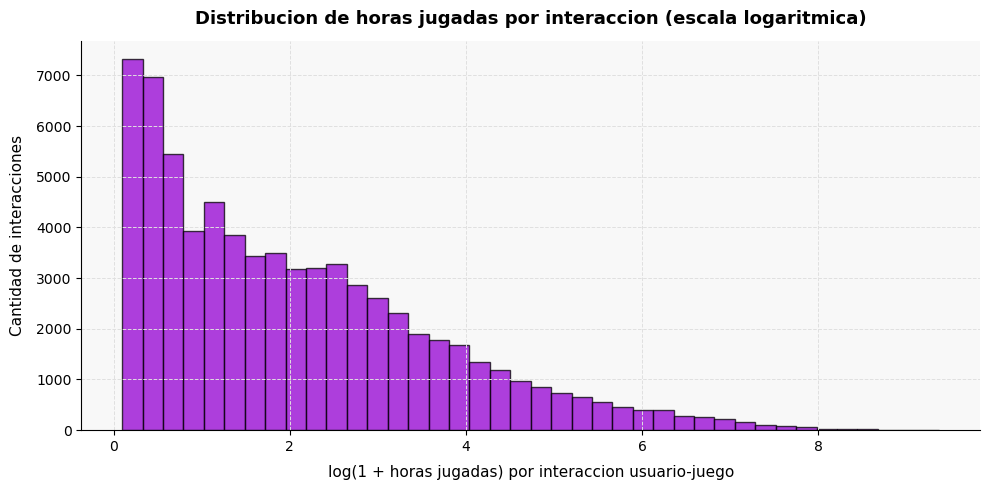

Horas jugadas — minimo: 0.1, mediana: 4.5, promedio: 48.9, maximo: 11,754


In [276]:
# Grafica 3 — Distribucion de las horas jugadas por interaccion (escala log)
horas = df.loc[df['behavior'] == 'play', 'value']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(horas), bins=40, color='#9400D3', alpha=0.75, edgecolor='Black')
ax.set_xlabel('log(1 + horas jugadas) por interaccion usuario-juego', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de interacciones', fontsize=11, labelpad=8)
ax.set_title('Distribucion de horas jugadas por interaccion (escala logaritmica)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('grafica_3_dist_horas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Horas jugadas — minimo: {horas.min()}, mediana: {horas.median()}, "
      f"promedio: {horas.mean():.1f}, maximo: {horas.max():,.0f}")

**Interpretacion**

La distribucion de horas jugadas por interaccion esta extremadamente sesgada a la derecha:
la mediana es apenas 4.5 horas, pero el maximo es 11,754 horas en un solo juego (un caso de
Dota 2). Tuvimos que graficar en escala logaritmica porque, en escala normal, casi todas las
barras se amontonarian cerca de cero y el histograma no se podria leer. Este hallazgo es
importante: cuando construyamos variables numericas por usuario en la Parte 2, este mismo
sesgo va a aparecer y sera necesario transformarlo antes de aplicar clustering (los
algoritmos basados en distancia son muy sensibles a valores extremos).

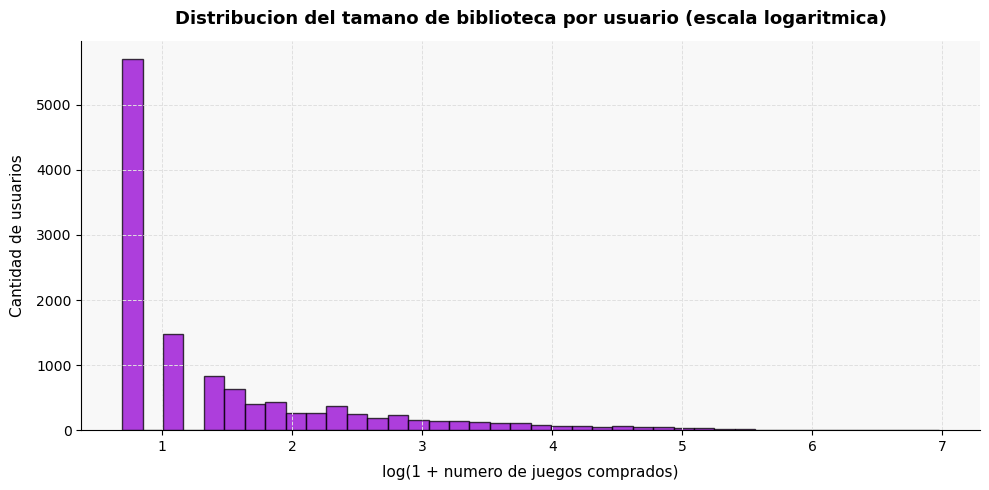

Juegos comprados por usuario — mediana: 2, promedio: 10.4, maximo: 1,068


In [257]:
# Grafica 4 — Distribucion del numero de juegos comprados por usuario (escala log)
juegos_por_usuario = df[df['behavior'] == 'purchase'].groupby('user_id')['game'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(juegos_por_usuario), bins=40, color='#9400D3', alpha=0.75, edgecolor='Black')
ax.set_xlabel('log(1 + numero de juegos comprados)', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de usuarios', fontsize=11, labelpad=8)
ax.set_title('Distribucion del tamano de biblioteca por usuario (escala logaritmica)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('grafica_4_dist_juegos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Juegos comprados por usuario — mediana: {juegos_por_usuario.median():.0f}, "
      f"promedio: {juegos_por_usuario.mean():.1f}, maximo: {juegos_por_usuario.max():,.0f}")

**Interpretacion**

La mayoria de los usuarios tiene bibliotecas pequenas (la mediana es de solo 2 juegos
comprados), pero hay un grupo reducido de "coleccionistas" con cientos de juegos — el
maximo llega a 1,068 juegos comprados por un solo usuario. Nuevamente aparece el mismo
patron de cola larga (long tail) que vimos con las horas jugadas. Esta es una senal fuerte
de que en los datos conviven varios perfiles de usuario muy distintos entre si, que es
justamente lo que el clustering deberia poder separar.

### Respuestas — Exploracion de datos

**Dimensiones y estructura**
> El dataset tiene 200,000 filas y 5 columnas, pero **no** esta organizado por usuario:
> cada fila es una interaccion usuario-juego (una compra o un registro de horas jugadas).
> Contiene 12,393 usuarios unicos y 5,155 juegos unicos.

**Tipos de variables**
> `user_id` y `value` son numericas; `game` y `behavior` son categoricas/texto. La columna
> `extra` es constante (siempre 0) y no aporta informacion.

**Calidad de los datos**
> No hay valores nulos. Si hay 707 filas duplicadas exactas (0.35% del total), que se
> eliminan en la Parte 2. El significado de `value` depende de `behavior`, lo cual hay que
> tener en cuenta al preparar los datos: no se puede promediar `value` directamente sin
> separar antes las filas de compra y las de horas jugadas.

**Hallazgo clave para el clustering**
> Tanto las horas jugadas como el numero de juegos por usuario siguen distribuciones muy
> sesgadas (pocos usuarios "extremos" concentran gran parte del volumen). Esto va a requerir
> una transformacion logaritmica antes de escalar y aplicar clustering.

---
## Parte 2 — Preparacion de los Datos

El reto central de este taller es que el dataset esta en formato de **interacciones**
(una fila = un evento usuario-juego), pero para hacer clustering necesitamos una fila
**por usuario**, con variables numericas que resuman su comportamiento completo. Esta
seccion documenta, paso a paso, como se hace esa transformacion y por que.

### 2.1 Limpieza inicial y separacion de comportamientos

In [258]:
# Eliminamos la columna 'extra' (siempre 0, sin informacion) y los 707 duplicados
# exactos detectados en la Parte 1. Trabajamos sobre df1 para no modificar el df original.
df1 = df.drop(columns=['extra']).drop_duplicates().copy()
print(f"Filas en df  (original): {len(df):,}")
print(f"Filas en df1 (sin duplicados): {len(df1):,}")

# 'value' significa cosas distintas segun 'behavior', asi que separamos las filas
# de compra y las filas de horas jugadas en dos tablas independientes.
compras = df1[df1['behavior'] == 'purchase']
horas_jugadas = df1[df1['behavior'] == 'play']

print(f"\nFilas de compra: {len(compras):,}")
print(f"Filas de horas jugadas: {len(horas_jugadas):,}")

# Verificamos un supuesto importante: todo juego con horas jugadas deberia tener
# tambien un registro de compra para el mismo usuario (no se puede jugar sin comprar).
verificacion = horas_jugadas.merge(compras[['user_id', 'game']], on=['user_id', 'game'],
                                    how='left', indicator=True)
print(f"\nRegistros de 'play' sin 'purchase' correspondiente: "
      f"{(verificacion['_merge'] == 'left_only').sum()}")

Filas en df  (original): 200,000
Filas en df1 (sin duplicados): 199,293

Filas de compra: 128,804
Filas de horas jugadas: 70,489

Registros de 'play' sin 'purchase' correspondiente: 0


**Por que separar las tablas**

`value` no significa lo mismo en ambos casos: en `purchase` siempre vale 1.0 (es solo una
bandera de "esto se compro"), mientras que en `play` es el numero de horas jugadas. Si se
promediara `value` sin separar, se estarian mezclando "compras" con "horas", lo cual no
tiene sentido. La verificacion confirma que todo registro de horas jugadas tiene su
compra asociada, como era de esperarse.

### 2.2 Construccion de variables por usuario

In [259]:
# Ahora s­i construimos la tabla a nivel de usuario, que es lo que necesita el clustering.
# Por cada usuario calculamos:
# - n_juegos_comprados: tamano de su biblioteca (cuantos juegos distintos compro)
# - n_juegos_jugados: cuantos de esos juegos realmente abrio y jugo
# - horas_totales: suma de horas jugadas en toda su biblioteca
# - horas_max: horas dedicadas a su juego favorito (el que mas jugo)
# - pct_jugados: que fraccion de lo que compro realmente llego a jugar

resumen_compras = compras.groupby('user_id').agg(
    n_juegos_comprados=('game', 'nunique')
).reset_index()

resumen_horas = horas_jugadas.groupby('user_id').agg(
    n_juegos_jugados=('game', 'nunique'),
    horas_totales=('value', 'sum'),
    horas_max=('value', 'max'),
).reset_index()

usuarios = resumen_compras.merge(resumen_horas, on='user_id', how='left')

# Los usuarios que compraron pero nunca aparecen en 'play' no tienen fila en resumen_horas,
# asi que el merge les deja NaN. Ese NaN significa "cero horas jugadas", no un dato faltante
# real, asi que se rellena con 0 (no con la mediana, porque aqui el 0 tiene un significado
# valido: nunca jugo nada de lo que compro).
cols_horas = ['n_juegos_jugados', 'horas_totales', 'horas_max']
usuarios[cols_horas] = usuarios[cols_horas].fillna(0)

usuarios['pct_jugados'] = usuarios['n_juegos_jugados'] / usuarios['n_juegos_comprados']

print(f"Usuarios en la tabla final: {usuarios.shape[0]:,}")
usuarios.head(8)

Usuarios en la tabla final: 12,393


,user_id,n_juegos_comprados,n_juegos_jugados,horas_totales,horas_max,pct_jugados
0,5250,21,6.0,225.5,144.0,0.285714
1,76767,36,20.0,1227.0,365.0,0.555556
2,86540,82,15.0,255.0,113.0,0.182927
3,103360,10,0.0,0.0,0.0,0.000000
4,144736,8,1.0,0.1,0.1,0.125000
5,181212,12,2.0,2.2,1.8,0.166667
6,229911,27,18.0,390.5,165.0,0.666667
7,298950,259,175.0,3745.4,1019.0,0.675676


**Interpretacion de las variables creadas**

Estas cinco variables capturan dos dimensiones de comportamiento distintas: **cuanto
compra** el usuario (`n_juegos_comprados`) y **cuanto realmente juega** de lo que compra
(`n_juegos_jugados`, `horas_totales`, `horas_max`, `pct_jugados`). Esta distincion es
justamente la que permite luego diferenciar, por ejemplo, a un coleccionista que compra
mucho pero juega poco de un jugador leal que compra poco pero juega intensamente esos
pocos juegos.

In [260]:
# Cuantos usuarios compraron algo pero nunca jugaron nada?
sin_horas = (usuarios['n_juegos_jugados'] == 0).sum()
print(f"Usuarios que compraron pero nunca registraron horas jugadas: {sin_horas:,} "
      f"({sin_horas/len(usuarios)*100:.1f}% del total)")

Usuarios que compraron pero nunca registraron horas jugadas: 1,043 (8.4% del total)


### 2.3 Distribucion y outliers de las variables numericas

In [261]:
cols_numericas = ['n_juegos_comprados', 'n_juegos_jugados', 'horas_totales',
                   'horas_max', 'pct_jugados']
usuarios[cols_numericas].describe().round(2)

,n_juegos_comprados,n_juegos_jugados,horas_totales,horas_max,pct_jugados
count,12393.00,12393.00,12393.00,12393.00,12393.00
mean,10.39,5.69,278.01,176.16,0.73
std,35.64,17.08,760.27,504.76,0.34
min,1.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,1.30,1.20,0.50
50%,2.00,1.00,13.50,11.60,1.00
75%,6.00,3.00,155.60,107.00,1.00
max,1068.00,498.00,11754.00,11754.00,1.00


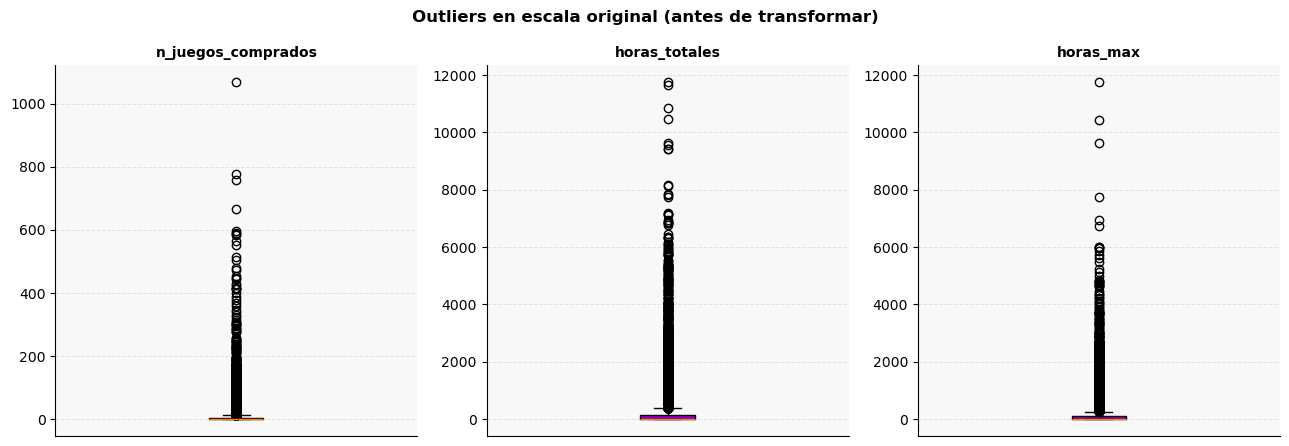

        user_id  n_juegos_comprados  horas_totales  horas_max  pct_jugados
2085   73017395                   1        11754.0    11754.0     1.000000
191    10599862                 257        11651.7     1061.0     0.692607
3236  100630947                  10        10853.2    10442.0     0.600000
532    26762388                 276        10470.1     1090.0     0.644928
5563  153382649                   2         9640.0     9640.0     0.500000


In [262]:
# Boxplots para visualizar que tan extremos son los outliers en escala original
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, ['n_juegos_comprados', 'horas_totales', 'horas_max']):
    ax.boxplot(usuarios[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#9400D3'))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xticks([])
plt.suptitle('Outliers en escala original (antes de transformar)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica_5_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(usuarios.sort_values('horas_totales', ascending=False)[
    ['user_id', 'n_juegos_comprados', 'horas_totales', 'horas_max', 'pct_jugados']
].head(5))

**Interpretacion**

El usuario con mas horas totales acumulo 11,754 horas — todas en un solo juego (Dota 2).
En escala original, este tipo de outliers dominarian por completo el calculo de distancias
del clustering: el algoritmo terminaria separando "ese usuario" de todos los demas en vez
de encontrar grupos que tengan sentido de negocio. Por eso, en vez de eliminar estos casos
(son datos reales y validos, no errores), se transforman.

### 2.4 Transformacion logaritmica

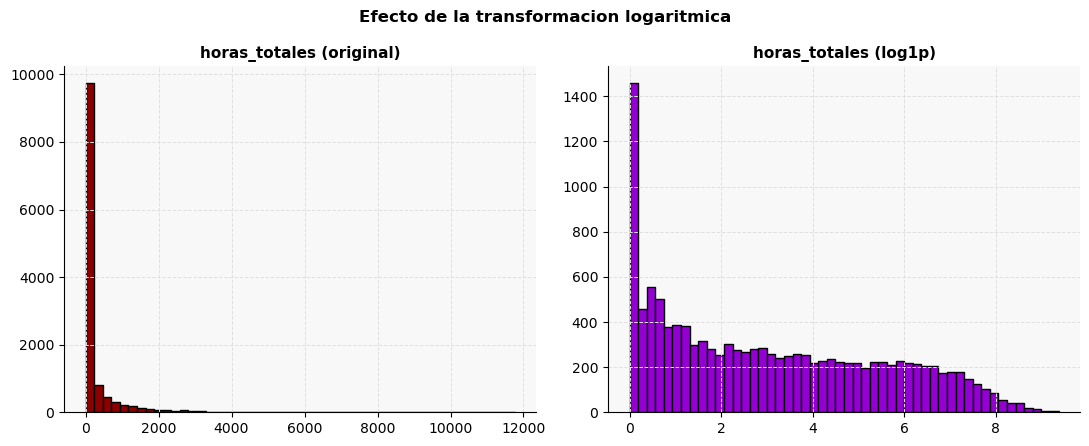

In [263]:
# Aplicamos log1p (log(1+x), que evita problemas con ceros) a las variables de conteo
# y de horas, que son las que mostraron el sesgo fuerte en la Parte 1 y en el paso anterior.
# pct_jugados no se transforma porque ya esta acotada entre 0 y 1, no tiene cola larga.

df1_usuarios = usuarios.copy()
cols_a_transformar = ['n_juegos_comprados', 'n_juegos_jugados', 'horas_totales', 'horas_max']

for col in cols_a_transformar:
    df1_usuarios[col + '_log'] = np.log1p(df1_usuarios[col])

# Comparacion visual: antes y despues de transformar 'horas_totales'
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(df1_usuarios['horas_totales'], bins=50, color='#8B0000', edgecolor='Black')
axes[0].set_title('horas_totales (original)', fontsize=11, fontweight='bold')
axes[1].hist(df1_usuarios['horas_totales_log'], bins=50, color='#9400D3', edgecolor='Black')
axes[1].set_title('horas_totales (log1p)', fontsize=11, fontweight='bold')
plt.suptitle('Efecto de la transformacion logaritmica', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica_6_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

Despues de aplicar `log1p`, la distribucion de `horas_totales` pasa de una cola extrema
concentrada casi toda en cero a una forma mucho mas simetrica y manejable. Esto reduce
el peso desproporcionado de los usuarios extremos sin eliminarlos del analisis — siguen
siendo los valores mas altos, pero ya no aplastan la escala para todos los demas.

### 2.5 Escalamiento de variables

In [264]:
# Las variables quedan en escalas muy distintas entre si (ej: n_juegos_comprados_log
# va de 0 a ~7, mientras que pct_jugados va de 0 a 1). K-Means usa distancia euclidiana,
# asi que si no se escalan, las variables con rangos mas grandes dominarian el calculo
# de distancias sin importar si son realmente mas importantes.

feature_cols = ['n_juegos_comprados_log', 'n_juegos_jugados_log',
                'horas_totales_log', 'horas_max_log', 'pct_jugados']

X = df1_usuarios[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables usadas para el clustering:")
print(feature_cols)
print(f"\nForma de la matriz escalada: {X_scaled.shape}")
print(f"Media por columna (deberia ser ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Desviacion por columna (deberia ser ~1): {X_scaled.std(axis=0).round(2)}")

Variables usadas para el clustering:
['n_juegos_comprados_log', 'n_juegos_jugados_log', 'horas_totales_log', 'horas_max_log', 'pct_jugados']

Forma de la matriz escalada: (12393, 5)
Media por columna (deberia ser ~0): [-0. -0. -0. -0.  0.]
Desviacion por columna (deberia ser ~1): [1. 1. 1. 1. 1.]


### Respuestas — Preparacion de datos

**Como se transformo el dataset de interacciones a variables por usuario?**
> Se separaron las filas de `purchase` y de `play` (porque `value` significa algo distinto
> en cada una), y se agruparon por `user_id` para calcular, por usuario: tamano de
> biblioteca, cantidad de juegos jugados, horas totales, horas en su juego favorito y
> porcentaje de lo comprado que efectivamente jugo.

**Que variables se eliminaron y por que?**
> `extra` (columna constante en 0, sin informacion) y los 707 registros duplicados exactos.
> `game` y `user_id` no se usan como variables predictoras del clustering: `game` porque el
> analisis es a nivel de usuario, no de juego, y `user_id` es solo un identificador.

**Que ingenieria de caracteristicas se aplico?**
> Se crearon variables derivadas (`pct_jugados`, `horas_max`) que combinan la informacion de
> compra y de juego, en vez de dejar solo conteos crudos. Tambien se aplico `log1p` a las
> variables de conteo y de horas, porque su distribucion original estaba fuertemente
> sesgada por unos pocos usuarios extremos (ej. el caso de 11,754 horas en Dota 2).

**Como se escalaron las variables?**
> Con `StandardScaler` (media 0, desviacion estandar 1), necesario porque K-Means calcula
> distancias euclidianas y las variables originales tenian escalas muy distintas entre si.

---
## Parte 3 — Modelado

**Eleccion del algoritmo**

Se evaluaron tres alternativas:

- **K-Means:** rapido, escala bien a los 12,393 usuarios del dataset, y produce clusters
  faciles de interpretar y de explicar a un equipo de negocio (cada cluster tiene un
  "centro" que se puede describir con un perfil promedio). Su principal limitacion es que
  asume clusters de forma mas o menos esferica y hay que elegir `k` de antemano.
- **DBSCAN:** util cuando los clusters tienen formas irregulares o hay ruido que se quiere
  descartar explicitamente. Se probo como referencia, pero con datos de comportamiento de
  usuario (variables continuas, sin una nocion clara de "densidad" espacial) tiende a
  producir un cluster gigante y muchos puntos marcados como ruido, lo cual es dificil de
  traducir en segmentos de negocio accionables.
- **Clustering jerarquico:** se uso como metodo de **validacion** (ver 3.3), no como
  modelo final, porque su costo computacional crece de forma cuadratica con el numero de
  usuarios y se vuelve poco practico para producccion con datasets que crecen con el tiempo.

Por estas razones se eligio **K-Means** como algoritmo principal, respaldado por
clustering jerarquico sobre una muestra para confirmar que la estructura de grupos
encontrada es consistente y no es un artefacto del algoritmo.

### 3.1 Metodo del codo y coeficiente de silueta

   k     inercia  silueta
0  2  33998.9064   0.4440
1  3  23531.4139   0.4470
2  4  15837.3588   0.4540
3  5  12965.9743   0.4484
4  6  10985.6911   0.4554
5  7   9520.3326   0.4542
6  8   8245.4133   0.4345


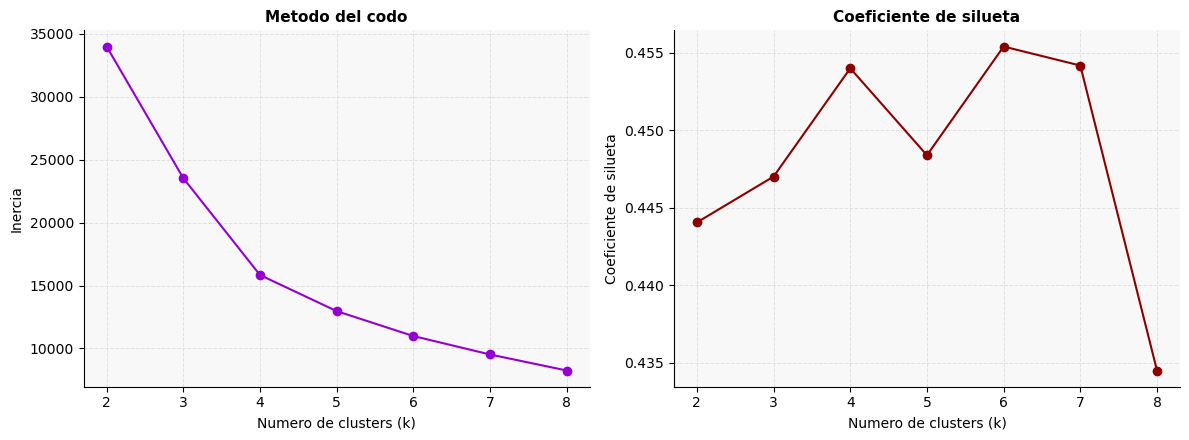

In [265]:
# Probamos distintos valores de k y medimos:
# - Inercia: que tan compactos son los clusters (suma de distancias al cuadrado al centro).
#   Baja siempre al aumentar k, por eso buscamos el punto donde deja de bajar tan rapido
#   ("el codo").
# - Silueta: mide que tan bien separado esta cada punto de los clusters vecinos (va de -1 a 1,
#   mayor es mejor). A diferencia de la inercia, no baja automaticamente con k mas alto.

resultados_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    resultados_k.append({'k': k, 'inercia': km.inertia_, 'silueta': sil})

resultados_k = pd.DataFrame(resultados_k)
print(resultados_k.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(resultados_k['k'], resultados_k['inercia'], marker='o', color='#9400D3')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo del codo', fontsize=11, fontweight='bold')

axes[1].plot(resultados_k['k'], resultados_k['silueta'], marker='o', color='#8B0000')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_7_codo_silueta.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

La inercia baja de forma pronunciada hasta `k=4` y despues la mejora se hace mucho mas
lenta ("el codo" del grafico). El coeficiente de silueta se mantiene bastante estable
entre 0.44 y 0.46 para todos los valores de k probados (el maximo es en k=6, con 0.455,
pero la diferencia con k=4, 0.454, es minima). Ante silhouettes practicamente empatados,
se elige **k=4**: da la mejor relacion entre calidad de separacion y facilidad de
interpretacion para el negocio, y coincide con la cantidad de segmentos tipicos que se
suelen usar en analisis de jugadores (casual, coleccionista, activo, frecuente).

### 3.2 Entrenamiento del modelo final (K-Means, k=4)

In [266]:
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df1_usuarios['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Modelo entrenado con k={k_final}")
print(f"\nUsuarios por cluster:")
conteo = df1_usuarios['cluster'].value_counts().sort_index()
for c, n in conteo.items():
    print(f"  Cluster {c}: {n:,} usuarios ({n/len(df1_usuarios)*100:.1f}%)")

print(f"\nSilueta del modelo final: {silhouette_score(X_scaled, df1_usuarios['cluster']):.4f}")

Modelo entrenado con k=4

Usuarios por cluster:
  Cluster 0: 1,691 usuarios (13.6%)
  Cluster 1: 4,888 usuarios (39.4%)
  Cluster 2: 2,279 usuarios (18.4%)
  Cluster 3: 3,535 usuarios (28.5%)

Silueta del modelo final: 0.4540


### 3.3 Validacion con clustering jerarquico

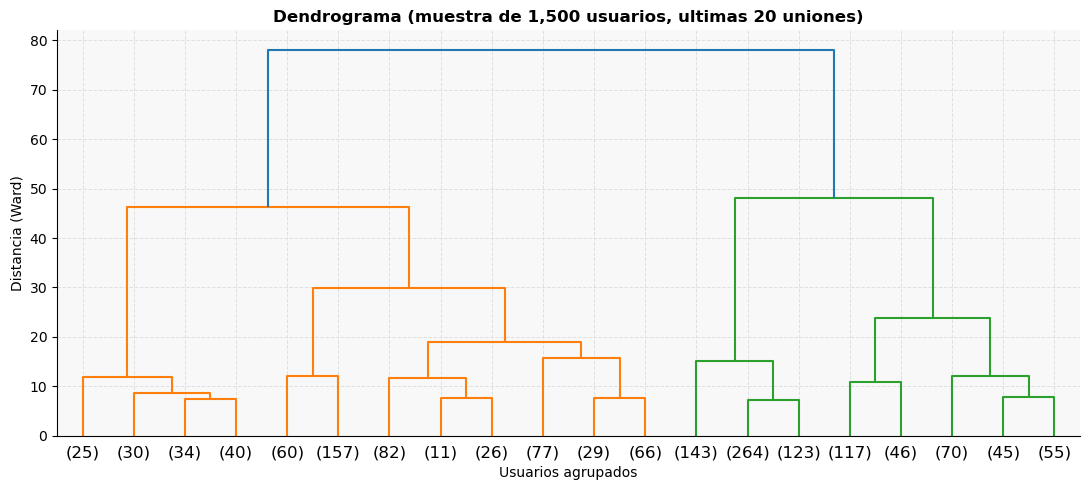

Distribucion de usuarios por grupo — clustering jerarquico (muestra):
1     8.6
2    33.9
3    35.3
4    22.2
Name: proportion, dtype: float64


In [267]:
# El clustering jerarquico (linkage de Ward) es demasiado costoso en memoria y tiempo
# para calcularlo sobre los 12,393 usuarios completos (crece de forma cuadratica), asi que
# se aplica sobre una muestra aleatoria de 1,500 usuarios, solo para verificar si encuentra
# una estructura de grupos parecida a la de K-Means (no para generar la segmentacion final).

rng = np.random.RandomState(42)
idx_muestra = rng.choice(len(X_scaled), 1500, replace=False)
X_muestra = X_scaled[idx_muestra]

Z = linkage(X_muestra, method='ward')

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(Z, truncate_mode='lastp', p=20, ax=ax, color_threshold=None)
ax.set_title('Dendrograma (muestra de 1,500 usuarios, ultimas 20 uniones)',
              fontsize=12, fontweight='bold')
ax.set_xlabel('Usuarios agrupados')
ax.set_ylabel('Distancia (Ward)')
plt.tight_layout()
plt.savefig('grafica_8_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

labels_jerarquico = fcluster(Z, t=4, criterion='maxclust')
conteo_jerarquico = pd.Series(labels_jerarquico).value_counts(normalize=True).sort_index() * 100
print("Distribucion de usuarios por grupo — clustering jerarquico (muestra):")
print(conteo_jerarquico.round(1))

**Interpretacion**

El dendrograma muestra una separacion clara en 4 grandes ramas antes de que las distancias
de union empiecen a crecer mucho, lo cual es consistente con la eleccion de `k=4` en
K-Means. Ademas, las proporciones de usuarios en cada grupo del clustering jerarquico
(sobre la muestra) son del mismo orden de magnitud que las de K-Means sobre el dataset
completo: un grupo grande de usuarios de bajo compromiso, un grupo intermedio de tamano
similar, y dos grupos mas pequenos de usuarios con comportamiento mas extremo (muy activos
o muy inactivos). Esta coincidencia entre dos algoritmos distintos da confianza en que la
segmentacion encontrada refleja una estructura real de los datos, y no es un artefacto de
un solo metodo.

### 3.4 Justificacion del algoritmo elegido

Se elige **K-Means con k=4** como modelo final porque:

1. **Escalabilidad:** corre en segundos sobre los 12,393 usuarios, y podria correr sobre
   millones de usuarios sin cambios estructurales — importante si esta segmentacion se va
   a recalcular periodicamente en produccion.
2. **Interpretabilidad:** cada cluster tiene un centro (perfil promedio) claro, facil de
   explicar a un equipo de marketing sin necesitar conocimientos tecnicos de clustering.
3. **Estabilidad:** el coeficiente de silueta es consistente (~0.45) en un rango amplio de
   valores de k, y la estructura de 4 grupos se confirma de forma independiente con
   clustering jerarquico sobre una muestra.
4. **DBSCAN se descarta** porque, al no haber una nocion clara de "densidad" espacial en
   variables de comportamiento como estas, tiende a fusionar la mayoria de los usuarios en
   un solo cluster grande y marcar como "ruido" a los casos mas extremos — que son
   justamente los usuarios mas interesantes para el negocio (los muy activos y los
   inactivos), y no deberian descartarse.

---
## Parte 4 — Interpretacion de los Clusters

### 4.1 Perfil promedio de cada cluster

In [268]:
cols_perfil = ['n_juegos_comprados', 'n_juegos_jugados', 'horas_totales',
               'horas_max', 'pct_jugados']

perfil = df1_usuarios.groupby('cluster')[cols_perfil].mean().round(2)
perfil['n_usuarios'] = df1_usuarios['cluster'].value_counts().sort_index()
perfil['% del total'] = (perfil['n_usuarios'] / len(df1_usuarios) * 100).round(1)
perfil

,n_juegos_comprados,n_juegos_jugados,horas_totales,horas_max,pct_jugados,n_usuarios,% del total
cluster,,,,,,,
0,58.01,31.35,1244.84,583.72,0.63,1691,13.6
1,1.28,1.23,6.44,6.09,0.99,4888,39.4
2,3.97,0.75,3.49,3.23,0.18,2279,18.4
3,4.35,2.75,368.01,327.86,0.76,3535,28.5


### 4.2 Visualizacion de los clusters (PCA a 2 dimensiones)

Varianza explicada por los 2 componentes: 87.5%


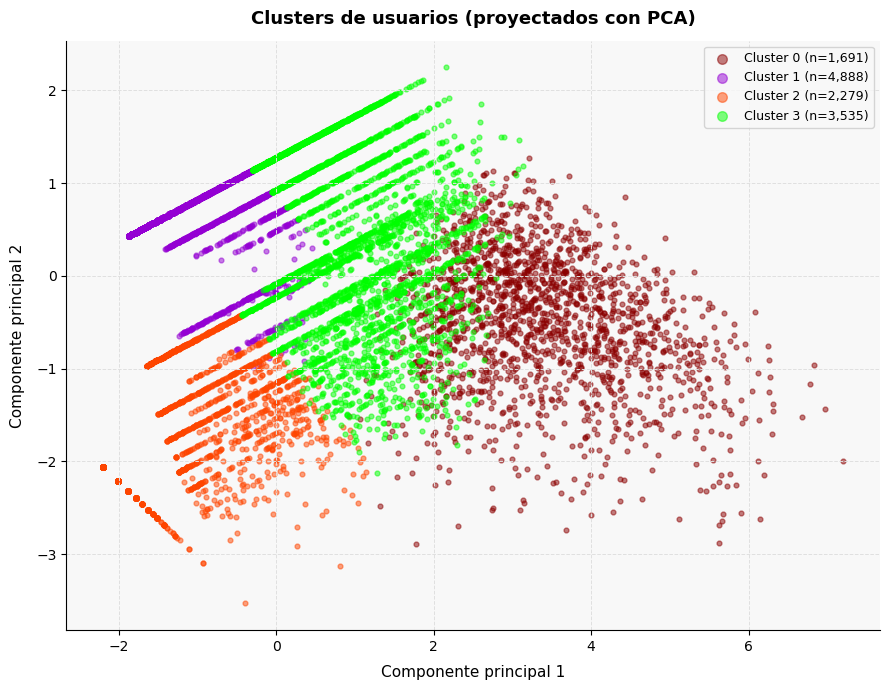

In [269]:
# PCA reduce las 5 variables escaladas a 2 componentes principales, solo para poder
# visualizar los clusters en un plano. El modelo de clustering ya esta entrenado sobre
# las 5 dimensiones originales — PCA aqui es unicamente una herramienta de visualizacion.

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_scaled)
df1_usuarios['pca_1'] = componentes[:, 0]
df1_usuarios['pca_2'] = componentes[:, 1]

print(f"Varianza explicada por los 2 componentes: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

colores = {0: '#8B0000', 1: '#9400D3', 2: '#FF4500', 3: '#00FF00'}

fig, ax = plt.subplots(figsize=(9, 7))
for c in sorted(df1_usuarios['cluster'].unique()):
    subset = df1_usuarios[df1_usuarios['cluster'] == c]
    ax.scatter(subset['pca_1'], subset['pca_2'], s=12, alpha=0.5,
               color=colores[c], label=f'Cluster {c} (n={len(subset):,})')

ax.set_xlabel('Componente principal 1', fontsize=11, labelpad=8)
ax.set_ylabel('Componente principal 2', fontsize=11, labelpad=8)
ax.set_title('Clusters de usuarios (proyectados con PCA)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('grafica_9_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

Los dos componentes principales capturan el 87.5% de la variabilidad total de las 5
variables originales, asi que este grafico en 2D es una representacion bastante fiel de la
estructura real de los datos (no es solo una simplificacion forzada). Se ven 4 zonas
razonablemente diferenciadas, con el cluster de usuarios de bajo compromiso concentrado en
una nube compacta y los clusters de usuarios mas activos extendiendose hacia valores mas
altos del primer componente, que esta fuertemente correlacionado con el volumen de
compra y de horas jugadas.

### 4.3 Comparacion de variables clave por cluster

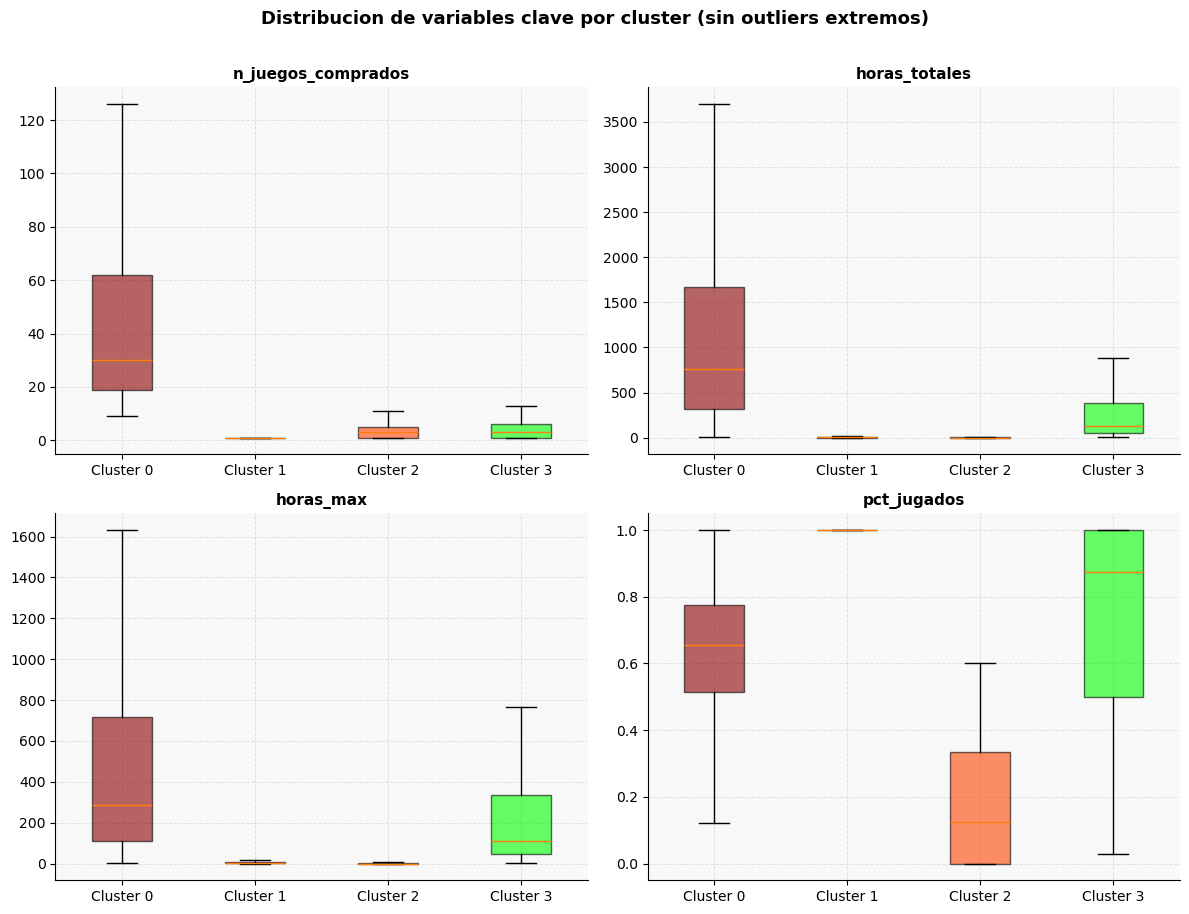

In [270]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
variables_a_graficar = ['n_juegos_comprados', 'horas_totales', 'horas_max', 'pct_jugados']

for ax, var in zip(axes.flat, variables_a_graficar):
    datos = [df1_usuarios.loc[df1_usuarios['cluster'] == c, var] for c in sorted(colores)]
    bp = ax.boxplot(datos, patch_artist=True, showfliers=False,
                     labels=[f'Cluster {c}' for c in sorted(colores)])
    for patch, c in zip(bp['boxes'], sorted(colores)):
        patch.set_facecolor(colores[c])
        patch.set_alpha(0.6)
    ax.set_title(var, fontsize=11, fontweight='bold')

plt.suptitle('Distribucion de variables clave por cluster (sin outliers extremos)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafica_10_boxplots_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Descripcion y nombre de cada segmento

**Cluster 1 — "Jugadores Casuales / de Prueba" (~4,888 usuarios, 39.4% del total)**
> Biblioteca minima (en promedio 1.3 juegos comprados), muy pocas horas jugadas en total
> (~6 horas) y `pct_jugados` cercano al 100%: practicamente todo lo que compran lo llegan a
> abrir, pero en dosis muy pequenas. Es el segmento mas grande del dataset. Son usuarios
> ocasionales — probablemente entraron a Steam para probar uno o dos juegos puntuales y no
> desarrollaron un habito de compra ni de juego frecuente.

**Cluster 2 — "Coleccionistas Inactivos" (~2,279 usuarios, 18.4% del total)**
> Compran una cantidad moderada de juegos (~4 en promedio) pero casi no los juegan
> (`pct_jugados` de apenas 18%, el mas bajo de los cuatro clusters) y acumulan muy pocas
> horas totales (~3.5 horas). Es el patron clasico de "compre en oferta y nunca lo abri":
> agregan juegos a su biblioteca (muchas veces durante rebajas) pero rara vez llegan a
> jugarlos.

**Cluster 3 — "Jugadores Frecuentes y Leales" (~3,535 usuarios, 28.5% del total)**
> Biblioteca de tamano similar a la del cluster anterior (~4-5 juegos), pero con un
> comportamiento de juego totalmente distinto: juegan la mayoria de lo que compran (76%) y
> acumulan bastantes horas (~368 en promedio, concentradas en pocos titulos favoritos, con
> ~328 horas en su juego principal). Son jugadores comprometidos que no necesitan una
> biblioteca enorme para estar activos — se quedan con pocos juegos que realmente disfrutan.

**Cluster 0 — "Usuarios Muy Activos / Power Users" (~1,691 usuarios, 13.6% del total)**
> El segmento mas pequeno mas no por eso menos importante: biblioteca grande (~58 juegos en
> promedio), juegan una porcion sustancial de ella (31 juegos jugados, 63% de lo comprado) y
> acumulan un volumen de horas muy alto (~1,245 horas totales, con hasta 584 horas en su
> juego favorito). Son los "super usuarios" de la plataforma: compran mucho y ademas usan
> gran parte de lo que compran.

**Diferencias clave entre clusters**
> El eje que mas separa a los clusters no es solo "cuanto compran", sino la **relacion
> entre lo que compran y lo que realmente juegan**. Los clusters 1 y 2 compran poco y
> moderado respectivamente, pero se diferencian en si juegan (Cluster 1, casi todo) o no
> (Cluster 2, casi nada) lo que compran. Los clusters 0 y 3 son los mas comprometidos en
> terminos de horas jugadas, pero se diferencian en el tamano de su biblioteca (0 es mucho
> mas grande que 3). Esta doble dimension — volumen de compra vs. profundidad de uso — es
> el hallazgo central del clustering.

---
## Parte 5 — Recomendaciones de Negocio

**Estrategia de marketing por segmento**

- **Jugadores Casuales / de Prueba (Cluster 1):** el objetivo es convertirlos en
  compradores recurrentes. Recomendaciones: campanas de descubrimiento ("si te gusto X,
  prueba Y") basadas en el unico o los pocos juegos que ya tienen, recomendaciones
  personalizadas de titulos similares a bajo precio, y notificaciones suaves de
  reenganche (por ejemplo, recordatorios de que su juego tuvo una actualizacion reciente).
  No conviene bombardearlos con ofertas agresivas de entrada, porque el riesgo es que
  perciban Steam como spam antes de haber generado un habito de uso.

- **Coleccionistas Inactivos (Cluster 2):** este grupo ya demostro disposicion a comprar,
  pero no a jugar. La prioridad no deberia ser venderles mas juegos, sino **activar lo que
  ya tienen**: recordatorios personalizados ("tienes X juegos sin abrir"), retos o
  recompensas cortas por iniciar sesion en un juego ya comprado, y contenido tipo "empieza
  aqui" para bajar la barrera de entrada. Ofrecerles descuentos en juegos nuevos antes de
  reactivar los que ya tienen corre el riesgo de perpetuar el patron de "comprar y no
  jugar".

- **Jugadores Frecuentes y Leales (Cluster 3):** son candidatos ideales para
  **contenido descargable (DLC), expansiones y secuelas** de sus juegos favoritos, asi
  como para programas de fidelizacion (insignias, recompensas por horas jugadas,
  invitaciones a eventos o betas). Tambien es un buen segmento para promociones de
  "amigos" (invita a un amigo a tu juego favorito), ya que su compromiso alto sugiere que
  podrian influir en su circulo social.

- **Usuarios Muy Activos / Power Users (Cluster 0):** son los usuarios de mayor valor de
  vida (lifetime value) y los mas indicados para **acceso anticipado**, membresias premium,
  descuentos por volumen en bundles, y programas VIP de fidelizacion. Tambien son la
  audiencia natural para encuestas de producto y pruebas beta, dado su alto nivel de
  involucramiento con la plataforma.

**Priorizacion para campanas de fidelizacion**

> Se priorizarian primero los **Usuarios Muy Activos** (Cluster 0), por su alto valor
> actual y su potencial como embajadores/influencers dentro de la comunidad, y en segundo
> lugar los **Jugadores Frecuentes y Leales** (Cluster 3), porque ya muestran un
> compromiso alto y probablemente respondan bien a incentivos de retencion con una
> inversion de marketing menor que la que requeriria convertir a un usuario casual. Los
> **Coleccionistas Inactivos** representan una oportunidad de "bajo costo, alto impacto"
> si se logra activarlos, mientras que los **Casuales** requieren una inversion mayor por
> usuario para generar el mismo efecto, por lo que se atenderian con campanas mas
> automatizadas y de menor costo por contacto.

**Informacion adicional que mejoraria la segmentacion**

> Este dataset solo tiene compras y horas jugadas — no incluye variables que serian muy
> valiosas para una segmentacion mas rica, como: fecha de la compra y fecha de la ultima
> sesion (para medir recencia, no solo volumen — un usuario "activo" hace un ano no es lo
> mismo que uno activo esta semana), monto gastado en dolares (aqui solo se sabe *que*
> compraron, no *cuanto pagaron*, y con descuentos eso puede variar mucho), genero de los
> juegos (para entender preferencias de contenido, no solo volumen de uso), plataforma de
> acceso (PC, Steam Deck, etc.), y datos demograficos basicos si estuvieran disponibles de
> forma agregada y respetando privacidad. Con esas variables se podria refinar la
> segmentacion actual e incluso construir modelos de prediccion de abandono (churn) o de
> recomendacion de proximo juego a comprar.

---
## Conclusiones del Taller

**Transformacion del dataset**
El reto principal de este taller no fue el clustering en si, sino transformar un dataset
de interacciones (200,000 filas, una por evento usuario-juego) en una tabla de 12,393
usuarios con variables de comportamiento significativas.

**Algoritmo y numero de clusters**
Se eligio K-Means con k=4, respaldado por el metodo del codo, el coeficiente de silueta
(~0.45, estable en un rango amplio de k) y una validacion independiente con clustering
jerarquico sobre una muestra, que encontro una estructura de grupos consistente.

**Segmentos encontrados**
Los cuatro segmentos — Jugadores Casuales, Coleccionistas Inactivos, Jugadores Frecuentes
y Leales, y Usuarios Muy Activos — se diferencian principalmente por dos dimensiones: el
volumen de compra y la profundidad real de uso (que tan grande es la parte de su
biblioteca que efectivamente juegan).

**Aplicacion de negocio**
Cada segmento requiere una estrategia de marketing distinta: activacion para los
coleccionistas inactivos, conversion gradual para los casuales, fidelizacion via DLC y
contenido social para los jugadores frecuentes, y programas VIP para los usuarios muy
activos. La informacion de fecha de compra, gasto real en dolares y genero de juego seria
el siguiente paso natural para enriquecer esta segmentacion.